# CE444: Geotechnical Design, Homework Assignment 5


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sy
from icecream import ic

## Problem 1

Solved on paper.

## Problem 2

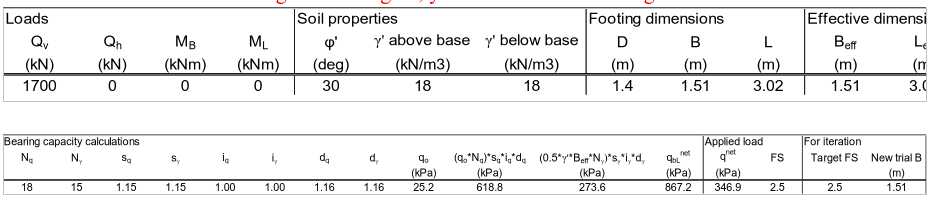

Correct answer: For friction angle of 45 degree, you should be calculating a foundation width of 0.47 m.

In [2]:
phis = np.linspace(30, 45, 16)
phiR = (np.pi/180) * phis
print(phis)
print(phiR)

[30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 45.]
[0.52359878 0.54105207 0.55850536 0.57595865 0.59341195 0.61086524
 0.62831853 0.64577182 0.66322512 0.68067841 0.6981317  0.71558499
 0.73303829 0.75049158 0.76794487 0.78539816]


In [3]:
# known values based on variables

saftey = 2.5
gamma_soil = 18 # kN/m^3
z_embed = 1.4 # m
q0 = gamma_soil * z_embed # kPa

i_q = 1
i_gamma = 1

s_q = (1 + (0.1/2) * ((1 + np.sin(np.radians(phis)))/ (1 - np.sin(np.radians(phis)))))
s_gamma = s_q

N_q = ((1 + np.sin(np.radians(phis)) )/ (1 - np.sin(np.radians(phis))) ) * np.exp(np.pi * np.tan(np.radians(phis)))

N_gamma = 1.5* (N_q - 1) * np.tan(np.radians(phis))

ic(saftey, gamma_soil, z_embed, q0, i_q, i_gamma, s_q, s_gamma, N_q, N_gamma)

ic| saftey: 2.5
    gamma_soil: 18
    z_embed: 1.4
    q0: 25.2
    i_q: 1
    i_gamma: 1
    s_q: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                1.29142136])
    s_gamma: array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
                    1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
                    1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
                    1.29142136])
    N_q: array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
                 29.43979237,  33.29609149,  37.75249717,  42.91991165,
                 48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
                 85.37362303,  99.01425896, 115.30790234, 134.87384063])
    N_gamma: array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
              

(2.5,
 18,
 1.4,
 25.2,
 1,
 1,
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([1.15      , 1.15620175, 1.16272942, 1.169606  , 1.1768566 ,
        1.18450862, 1.192592  , 1.20113956, 1.21018729, 1.21977475,
        1.2299455 , 1.24074757, 1.25223406, 1.26446379, 1.27750202,
        1.29142136]),
 array([ 18.40112222,  20.63079316,  23.17677621,  26.0920121 ,
         29.43979237,  33.29609149,  37.75249717,  42.91991165,
         48.9332527 ,  55.95745874,  64.19520639,  73.89689143,
         85.37362303,  99.01425896, 115.30790234, 134.87384063]),
 array([ 15.0698139 ,  17.6930558 ,  20.78638166,  24.44241478,
         28.77432326,  33.92095008,  40.05337831,  47.38337881,
         56.17434205,  66.75550889,  79.54061156,  95.05245142,
        113.95552712, 137.09966271, 165.57878724, 200.81076094]))

In [4]:
# solvables 

B = sy.Symbol('B') 

widths = np.zeros(len(phis)) # initializing array
sin_frac = np.sqrt((1 + np.sin(phiR)) / (1 - np.sin(phiR)))
ic(sin_frac)

for i in range(len(widths)):
    depth_factor = (1 + (0.1*(z_embed/B)*sin_frac))
    surcharge_term = q0 * float(N_q[i]) * float(s_q[i]) * i_q * depth_factor[i]
    gamma_term = 0.5*gamma_soil*B*float(N_gamma[i])*float(s_gamma[i])*i_gamma * (depth_factor[i])
    q_bL_net_cap = ((1.7*10**3)/(2*B**2) - q0)*2.5
    widths[i] = sy.solve(surcharge_term + gamma_term - q0 - q_bL_net_cap)[0]

ic(widths)

ic| sin_frac: array([1.73205081, 1.76749402, 1.80404776, 1.84177089, 1.88072647,
                     1.92098213, 1.96261051, 2.00568971, 2.05030384, 2.0965436 ,
                     2.14450692, 2.19429973, 2.24603677, 2.29984255, 2.35585237,
                     2.41421356])
ic| widths: array([1.51145397, 1.42201686, 1.33585339, 1.25285712, 1.17292768,
                   1.09597105, 1.02189972, 0.95063285, 0.88209651, 0.81622384,
                   0.75295536, 0.69223934, 0.63403229, 0.57829953, 0.52501597,
                   0.474167  ])


array([1.51145397, 1.42201686, 1.33585339, 1.25285712, 1.17292768,
       1.09597105, 1.02189972, 0.95063285, 0.88209651, 0.81622384,
       0.75295536, 0.69223934, 0.63403229, 0.57829953, 0.52501597,
       0.474167  ])

In [5]:
# back calc to check FS = 2.5
q_bL_net_backcalc = np.zeros(len(phis))
q_bL_net_demand = np.zeros(len(phis))

depth_factor = (1 + (0.1*(z_embed/widths)*sin_frac))

print(1 + (0.1*(1.4/1.51146827646477)*(sin_frac[0])))

ic(depth_factor)
surcharge_term = q0 * N_q * s_q * i_q * depth_factor
gamma_term = 0.5*gamma_soil*widths*N_gamma*s_gamma*i_gamma*depth_factor
q_bL_net_backcalc = surcharge_term + gamma_term - q0
q_bL_net_demand = (1.7*10**3)/(2*widths**2) - q0

ic(q_bL_net_backcalc)
ic(q_bL_net_demand)

FS = q_bL_net_backcalc/q_bL_net_demand

ic(FS)


1.1604314935585713


ic| depth_factor: array([1.16043301, 1.17401282, 1.18906767, 1.20580792, 1.22448247,
                         1.24538741, 1.26887714, 1.29537856, 1.32540945, 1.35960246,
                         1.39873675, 1.44377998, 1.495945  , 1.55676676, 1.62820819,
                         1.71280772])
ic| q_bL_net_backcalc: array([ 867.18446095,  987.87109168, 1127.80688806, 1290.80415467,
                              1481.60153458, 1706.13416244, 1971.89674725, 2288.43671805,
                              2668.03158693, 3126.63055909, 3685.18033192, 4371.51753686,
                              5223.10978522, 6291.08840339, 7646.28158218, 9388.40299753])
ic| q_bL_net_demand: array([ 346.87378438,  395.14843667,  451.12275523,  516.32166187,
                             592.64061383,  682.45366498,  788.7586989 ,  915.37468722,
                            1067.21263477, 1250.65222364, 1474.07213277, 1748.60701474,
                            2089.24391409, 2516.43536136, 3058.51263287, 3755.3611

array([2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5,
       2.5, 2.5, 2.5])

In [6]:
problem2_table = pd.DataFrame({"phi": phis, "B": widths, "L": 2*widths, \
    "N_q": N_q, "s_q": s_q, "i_q": i_q, "d_q": depth_factor,\
    "N_gamma": N_gamma, "s_gamma": s_gamma,  "i_gamma": i_gamma, "d_gamma": depth_factor, \
    "q_bL_net_capacity": q_bL_net_backcalc, "q_bL_net_demand": q_bL_net_demand, "FS": np.round(FS,1)})

problem2_table.reset_index(drop=True, inplace=True)

In [7]:
problem2_table.to_latex()

'\\begin{tabular}{lrrrrrrrrrrrrrr}\n\\toprule\n & phi & B & L & N_q & s_q & i_q & d_q & N_gamma & s_gamma & i_gamma & d_gamma & q_bL_net_capacity & q_bL_net_demand & FS \\\\\n\\midrule\n0 & 30.000000 & 1.511454 & 3.022908 & 18.401122 & 1.150000 & 1 & 1.160433 & 15.069814 & 1.150000 & 1 & 1.160433 & 867.184461 & 346.873784 & 2.500000 \\\\\n1 & 31.000000 & 1.422017 & 2.844034 & 20.630793 & 1.156202 & 1 & 1.174013 & 17.693056 & 1.156202 & 1 & 1.174013 & 987.871092 & 395.148437 & 2.500000 \\\\\n2 & 32.000000 & 1.335853 & 2.671707 & 23.176776 & 1.162729 & 1 & 1.189068 & 20.786382 & 1.162729 & 1 & 1.189068 & 1127.806888 & 451.122755 & 2.500000 \\\\\n3 & 33.000000 & 1.252857 & 2.505714 & 26.092012 & 1.169606 & 1 & 1.205808 & 24.442415 & 1.169606 & 1 & 1.205808 & 1290.804155 & 516.321662 & 2.500000 \\\\\n4 & 34.000000 & 1.172928 & 2.345855 & 29.439792 & 1.176857 & 1 & 1.224482 & 28.774323 & 1.176857 & 1 & 1.224482 & 1481.601535 & 592.640614 & 2.500000 \\\\\n5 & 35.000000 & 1.095971 & 2.191942 

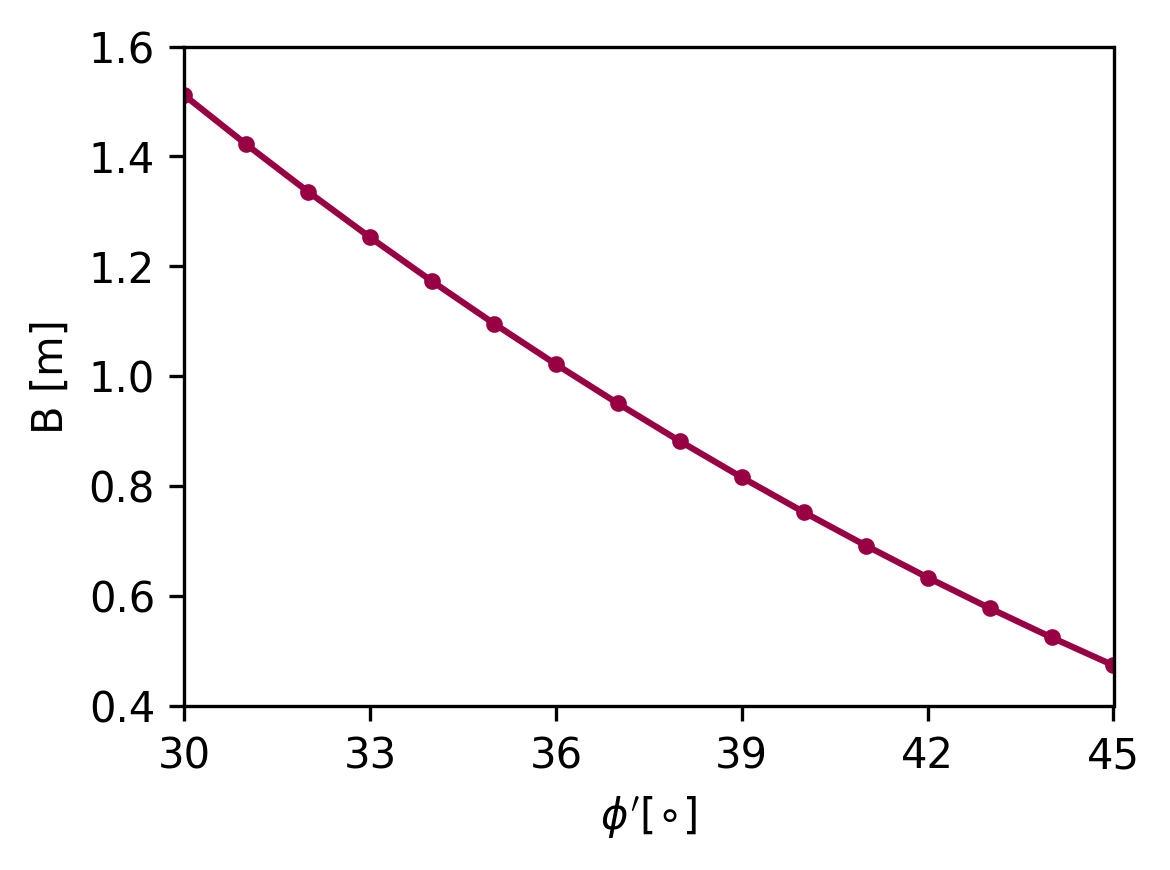

In [8]:
fig, ax = plt.subplots(figsize=(4,3), tight_layout = True, dpi = 300)

ax.plot(phis, widths, '.', linestyle = '-', color = "#980043" )
ax.set_xlabel("$\\phi' [\\circ]$")
ax.set_ylabel('B [m]')

ax.set_ylim(0.4, 1.6)
ax.set_xlim(30, 45)
ax.set_xticks(np.linspace(30, 45, 6))

## Problem 3

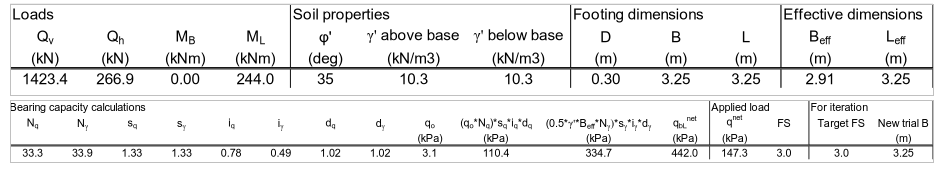

In [9]:
# convert all values into SI from US customary units
Qv = 320 * 1000 * 4.448 / 1000 # from kips to kN
Qh = 60 * 1000 * 4.448 / 1000 # from kips to kN
M = 180 * 1000 * 4.448 / 3.281 / 1000 # from k-ft to kNm
eff_gamma = (128 * 4.448 * (3.281**3) /1000) - 9.81 # from pcf to kNm^-3

ic(Qv, Qh, M, eff_gamma)

ic| Qv: 1423.3600000000001
    Qh: 266.88
    M: 244.02316366961296
    eff_gamma: 10.299137300271108


(1423.3600000000001, 266.88, 244.02316366961296, 10.299137300271108)

In [27]:
# decide the range of embedded depths to test
z_embed_p3 = np.linspace(1, 6, 6)*0.3048  # [1,6] m but converted to ft
# z_embed_p3 = np.arange(0.3, 1.8, 0.1)
widths_p3 = np.zeros(len(z_embed_p3)) # initialize array for widths

# compute eccentricity and B_eff
e = M / Qv # in m

ic(z_embed_p3, e)

ic| z_embed_p3: array([0.3048, 0.6096, 0.9144, 1.2192, 1.524 , 1.8288])
    e: 0.17144163364827797


(array([0.3048, 0.6096, 0.9144, 1.2192, 1.524 , 1.8288]), 0.17144163364827797)

In [62]:
# setup knowns for problem 3
phi_p3 = 35 # in degrees
sin_frac_p3 = (1 + np.sin(np.radians(phi_p3)))/ (1 - np.sin(np.radians(phi_p3))) 
beta_p3 = np.degrees(np.atan(Qh/Qv)) # in degrees

Nq_p3 = sin_frac_p3 * np.exp(np.pi * np.tan(np.radians(phi_p3)))
iq_p3 = (1-(beta_p3/90))**2
Ngamma_p3 = 1.5 * (Nq_p3 - 1) * np.tan(np.radians(phi_p3))
igamma_p3 = (1 - (beta_p3/phi_p3))**2 

ic(phi_p3, sin_frac_p3, beta_p3)
ic(Nq_p3, iq_p3, Ngamma_p3, igamma_p3)

ic| phi_p3: 35
    sin_frac_p3: np.float64(3.6901723321426636)
    beta_p3: np.float64(10.619655276155132)
ic| Nq_p3: np.float64(33.29609149141175)
    iq_p3: np.float64(0.7779307566020304)
    Ngamma_p3: np.float64(33.92095007549546)
    igamma_p3: np.float64(0.4852254766151105)


(np.float64(33.29609149141175),
 np.float64(0.7779307566020304),
 np.float64(33.92095007549546),
 np.float64(0.4852254766151105))

In [63]:
# decide factor of safety desired
safety_p3 = 3

In [64]:
# setup unknowns for problem 3
B3 = sy.Symbol('B3') # B for problem 3
B_eff = B3 - (2*e) # effective B for problem 3
L_eff = B3

for i in range(len(z_embed_p3)):
    q0_eff_p3 = eff_gamma * z_embed_p3[i]
    depth_factor_p3 = 1 + (0.1*((z_embed_p3[i])/(B_eff))*np.sqrt(sin_frac_p3))
    sq_p3 = 1 + 0.1*(B_eff/L_eff)*sin_frac_p3
    sgamma_p3 = sq_p3

    # capacity term
    qbLnet_cap_p3 = (q0_eff_p3*Nq_p3*sq_p3*iq_p3*depth_factor_p3) + (0.5*eff_gamma*B_eff*Ngamma_p3*sgamma_p3*igamma_p3*depth_factor_p3) - q0_eff_p3

    # demand term
    qbLnet_dem_p3 = (Qv / (B_eff*L_eff)) - q0_eff_p3

    widths_p3[i] = sy.solve(qbLnet_cap_p3 - (safety_p3 * qbLnet_dem_p3))[0]

ic(widths_p3) # something is barely off...

ic| widths_p3: array([3.25245145, 2.9717244 , 2.73435272, 2.5312424 , 2.35527764,
                      2.20099858])


array([3.25245145, 2.9717244 , 2.73435272, 2.5312424 , 2.35527764,
       2.20099858])

In [65]:
# check capacities and demands based on solved widths

capacity_p3 = np.zeros(len(z_embed_p3)) # initialize capacity
demand_p3 = np.zeros(len(z_embed_p3)) # initialize demand
B_eff_p3 = widths_p3 - 2*e

q0_eff_p3 = eff_gamma * z_embed_p3
depth_factor_p3 = 1 + (0.1*((z_embed_p3)/(B_eff_p3))*np.sqrt(sin_frac_p3))
sq_p3 = 1 + 0.1*(B_eff_p3/widths_p3)*sin_frac_p3
sgamma_p3 = sq_p3
ic(depth_factor_p3, sq_p3)


# capacity term
capacity_p3 = (q0_eff_p3*Nq_p3*sq_p3*iq_p3*depth_factor_p3) + \
    (0.5*eff_gamma*B_eff_p3*Ngamma_p3*sgamma_p3*igamma_p3*depth_factor_p3) \
        - q0_eff_p3

# demand term
demand_p3 = (Qv / (B_eff_p3*widths_p3)) - q0_eff_p3

FS_p3 = capacity_p3 / demand_p3

ic(widths_p3, capacity_p3, demand_p3, FS_p3)

ic| depth_factor_p3: array([1.02012379, 1.04454551, 1.07345049, 1.10702363, 1.14547729,
                            1.1890675 ])
    sq_p3: array([1.33011432, 1.32643932, 1.32274309, 1.31902999, 1.3152954 ,
                  1.31152977])
ic| widths_p3: array([3.25245145, 2.9717244 , 2.73435272, 2.5312424 , 2.35527764,
                      2.20099858])
    capacity_p3: array([441.81110175, 527.75677337, 624.75260189, 733.20437642,
                        853.82110143, 987.59839729])
    demand_p3: array([147.27036725, 175.91892446, 208.2508673 , 244.40145881,
                      284.60703381, 329.19946576])
    FS_p3: array([3., 3., 3., 3., 3., 3.])


(array([3.25245145, 2.9717244 , 2.73435272, 2.5312424 , 2.35527764,
        2.20099858]),
 array([441.81110175, 527.75677337, 624.75260189, 733.20437642,
        853.82110143, 987.59839729]),
 array([147.27036725, 175.91892446, 208.2508673 , 244.40145881,
        284.60703381, 329.19946576]),
 array([3., 3., 3., 3., 3., 3.]))

(0.0, 2.0)

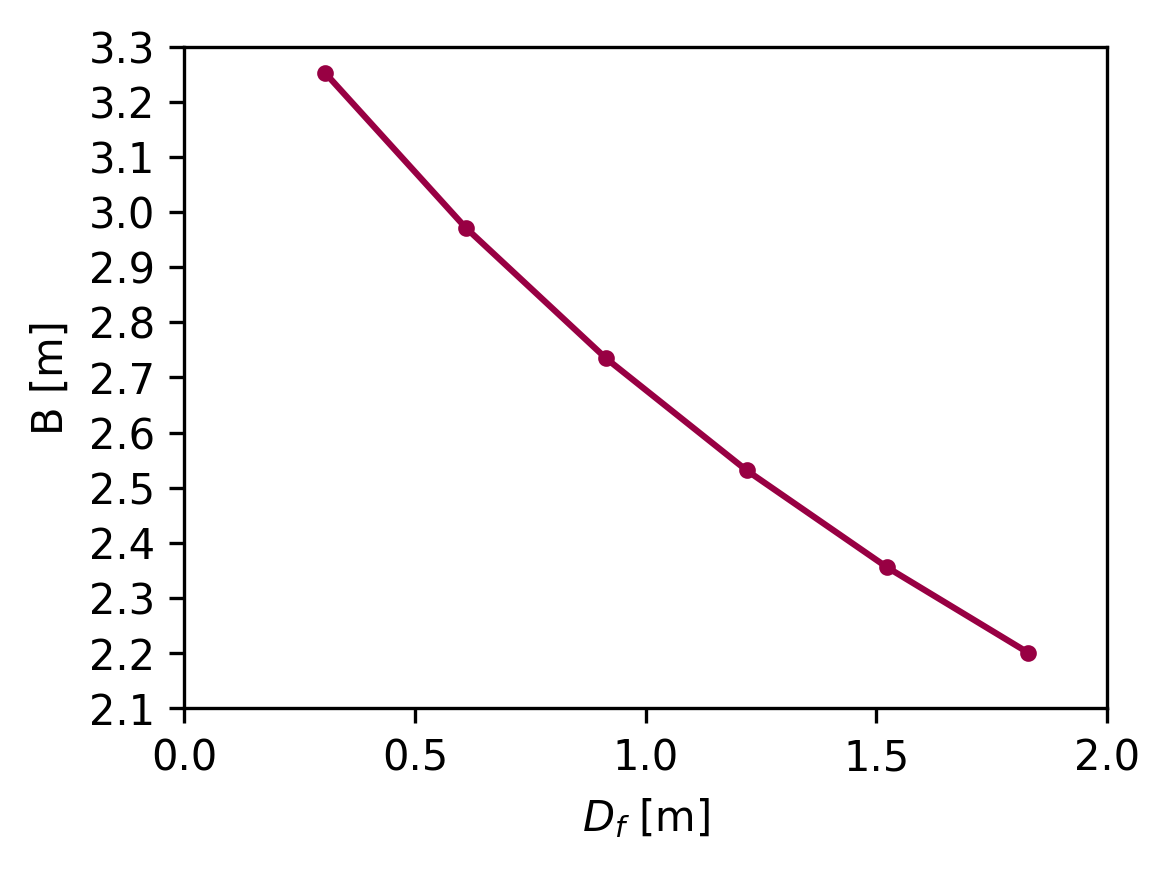

In [66]:
fig, ax = plt.subplots(figsize=(4,3), tight_layout = True, dpi = 300)

ax.plot(z_embed_p3, widths_p3, '.', linestyle = '-', color = "#980043" )
ax.set_xlabel("$D_f$ [m]")
ax.set_ylabel('B [m]')

ax.set_ylim(2.1, 3.3)
ax.set_yticks(np.arange(2.1,3.4,0.1))
ax.set_xlim(0, 2)
# ax.set_xticks(np.linspace(30, 45, 6))